In [38]:
# Enable autoreload of local Python modules (e.g., models)
%load_ext autoreload
%autoreload 0

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
import jax
import flax
print("JAX version:", jax.__version__)
print("Devices:", jax.devices())

JAX version: 0.8.0
Devices: [CudaDevice(id=0)]


In [40]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import jax
import jax.numpy as jnp
import optax
import time

# local imports
import models.models as models
import util.generation as generation


In [41]:
# initialize the jax random key
key = jax.random.key(0)

# Load data

In [42]:
# load the ./data/text8_train.txt and ./data/text8_test.txt files
with open("./data/text8_train.txt", "r") as f:
    train_text = f.read()
with open("./data/text8_test.txt", "r") as f:
    test_text = f.read()

# print the length of the training text and test text
print(f"Length of training text: {len(train_text):_} characters")
print(f"Length of test text: {len(test_text):_} characters")



Length of training text: 90_000_000 characters
Length of test text: 5_000_000 characters


In [43]:
# Build vocabulary (lowercase + space + a few punctuations)
char_set = list("abcdefghijklmnopqrstuvwxyz ")
char_to_int = {ch:i for i,ch in enumerate(char_set)}
int_to_char = {i:ch for ch,i in char_to_int.items()}

def encode(s):
    """Encode string to array of integers"""
    ids = [char_to_int[c] for c in s]
    return np.array(ids, dtype=np.uint8)  # use np.uint8 to save space

In [44]:
# encode the text
train_text_int = encode(train_text)
test_text_int = encode(test_text)

In [45]:
split_idx = int(len(train_text_int) * 0.9)  # 90% train, 10% val
train_text_int = train_text_int[:split_idx]
val_text_int   = train_text_int[split_idx:]

In [46]:
print(train_text_int)

[26  0 13 ...  5 14 17]


In [11]:
# sanity check: display a few random characters from the training text
T = 128
for _ in range(5):
    # choose random position in text
    N = np.random.randint(low=0, high=len(train_text)-T)
    print(train_text[N:N+T])
    print()

vasilievich was the name and patronymic of the notorious sixteenth century tsar ivan the terrible in bulgakov s novel ivan vasil

r pastrami sandwich this bit is also seen with other good bad interjections perhaps that s fortunate unfortunate or even with a 

graphy annotated bibliography for glenn seaborg from the alsos digital library books the actinide elements with joseph katz mcgr

s and other identity deceptions attempt to both distinguish real from trolling postings and upon judging a poster a troll make t

ead moves much faster than a tactical missile warhead however it s possible the higher performance thaad missile could be upgrad



# Create a basic Transformer model

In [47]:
def create_train_state(rng, vocab_size, d_model, n_layers, n_heads, max_len, dropout_rate):
    model = models.DecoderOnlyTransformer(vocab_size=vocab_size, d_model=d_model, n_layers=n_layers, n_heads=n_heads, max_len=max_len, dropout_rate=dropout_rate)
    params = model.init(rng, jnp.ones((1, max_len), jnp.int32))["params"]
    return model, params


In [48]:
# vocab size
vocab_size= len(char_set)

# internal model dimensions
d_model=512

# number of attention heads
n_heads=8

# number of Transformer layers
n_layers=4

# maximum sequence length
max_len=128

dropout_rate=0.1

model, params = create_train_state(key, vocab_size, d_model, n_layers, n_heads, max_len, dropout_rate)

In [14]:
# compute the number of parameters
def count_params(params):
    return sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Number of parameters: {count_params(params):_}")

Number of parameters: 4_507_852


In [15]:
# sanity check: create a batch of data & run a forward pass
B, T = 4, 32
batch = jax.random.randint(
    key=key,
    shape=(B, T), minval=0, maxval=len(char_set))
logits = model.apply({"params": params}, batch, train=True, rngs={"dropout": key},)

print("batch shape:", batch.shape)  # (B, T)
print("logits shape:", logits.shape)  # (B, T, vocab_size)

batch shape: (4, 32)
logits shape: (4, 32, 27)


# Loss function

In [50]:
@jax.jit
def loss_and_metrics(logits, targets):
    """Compute cross-entropy loss and accuracy.

    Assumes `targets` contains only valid integer class ids in [0, V-1] (no -1 ignore tokens).

    Args:
      logits: (B, T, V) float array of unnormalized scores.
      targets: (B, T) integer array with ground-truth class ids.

    Returns:
      loss: scalar average cross-entropy over all positions.
      metrics: dict with keys "loss" and "acc" (both scalars).
    """
    # Flatten batch/time dims so optax works on shape (N, V) and (N,)
    vocab = logits.shape[-1]
    flat_logits = logits.reshape(-1, vocab)
    flat_targets = targets.reshape(-1)

    # Per-position cross-entropy, then mean over all positions
    per_pos = optax.softmax_cross_entropy_with_integer_labels(flat_logits, flat_targets)
    loss = per_pos.mean()

    # prediction over all positions
    preds = jnp.argmax(logits, axis=-1)  # (B, T)
    
    # compute accuracy over only the last position
    is_match = preds == targets
    
    # Accuracy over all positions
    acc_all = jnp.mean(is_match.astype(jnp.float32))
    
    # Accuracy over only last position
    acc_last = jnp.mean(is_match.astype(jnp.float32)[:,-1])

    return loss, {"loss": loss, "acc": acc_all, "acc_last": acc_last}

# Optimization step:

In [51]:
# create an update function
def train_step(params, opt_state, x, y, tx, rng):
    """Single optimization step using optax optimizer.

    Args:
      params: pytree of model parameters.
      opt_state: optax optimizer state corresponding to `params`.
      x: (B, T) int array input tokens.
      y: (B, T) int array target tokens.
      tx: optax.GradientTransformation (already initialized).

    Returns:
      new_params: updated parameters after one gradient step.
      new_opt_state: updated optimizer state.
      metrics: dict of scalar metrics (loss, acc).
    """
    def loss_fn(params):
        logits = model.apply({"params": params}, x, train=True, rngs={"dropout": rng})
        loss, metrics = loss_and_metrics(logits, y)
        return loss, metrics

    # compute gradients (loss is scalar, metrics is auxiliary)
    (loss, metrics), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # optax update: compute parameter updates and new optimizer state
    updates, new_opt_state = tx.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, metrics

# jit: last argument should be static because it is an object
train_step = jax.jit(train_step, static_argnames=("tx",))

# Batch creation:

In [52]:
# create a batch from the training data
def get_batch(text_int, B, T):
    """Create a random batch of data from text_int.

    Args:
      text_int: 1D array of token ids.
      B: batch size (number of sequences).
      T: sequence length (number of tokens per sequence).

    Returns:
      x: (B, T) int array input tokens.
      y: (B, T) int array target tokens.
    """
    # choose random starting indices for each sequence in the batch
    ix = np.random.randint(0, len(text_int) - T, size=B)
    # inputs are text from i to i+T
    x = np.stack([text_int[i:i+T] for i in ix])
    # targets are text from i+1 to i+T+1
    y = np.stack([text_int[i+1:i+T+1] for i in ix])
    return jnp.array(x, dtype=jnp.int32), jnp.array(y, dtype=jnp.int32)

In [53]:
def get_val_batch(text_int, B, T):
    # Sequential sampling to avoid randomness
    start_idx = np.random.randint(0, len(text_int) - T, size=B)
    x = np.stack([text_int[i:i+T] for i in start_idx])
    y = np.stack([text_int[i+1:i+T+1] for i in start_idx])
    return jnp.array(x, dtype=jnp.int32), jnp.array(y, dtype=jnp.int32)

# Optimizer creation:

In [54]:
# define optax optimizer
learning_rate = 0.001
# Create Adam optimizer (Optax)
tx = optax.adam(learning_rate=learning_rate)
# Initialize optimizer state for current params
opt_state = tx.init(params)
print(f"Initialized optimizer: Adam lr={learning_rate}")



Initialized optimizer: Adam lr=0.001


In [55]:
import optuna

def sample_hyperparams(trial):
    return {
        "d_model": trial.suggest_categorical("d_model", [64, 128, 256, 512]),
        "n_layers": trial.suggest_int("n_layers", 2, 6),
        "n_heads": trial.suggest_categorical("n_heads", [2, 4, 8]),
        "dropout_rate": trial.suggest_float("dropout_rate", 0.0, 0.3),
        "learning_rate": trial.suggest_loguniform("learning_rate", 1e-4, 1e-2),
    }


In [56]:
def objective(trial):
    flax.core.scope._root = None
    hparams = sample_hyperparams(trial)
    rng = jax.random.PRNGKey(trial.number)
    
    # fresh model & params per trial
    model = models.DecoderOnlyTransformer(
        vocab_size=len(char_set),
        d_model=hparams["d_model"],
        n_layers=hparams["n_layers"],
        n_heads=hparams["n_heads"],
        max_len=128,
        dropout_rate=hparams["dropout_rate"]
    )
    
    # initialize params from scratch
    params = model.init(rng, jnp.ones((1, 128), jnp.int32))["params"]
    
    # optimizer
    tx = optax.adam(hparams["learning_rate"])
    opt_state = tx.init(params)
    
    # training loop
    num_batches = 10
    batch_size = 16
    seq_len = 128
    for _ in range(num_batches):
        x, y = get_batch(train_text_int, batch_size, seq_len)
        rng, subkey = jax.random.split(rng)
        params, opt_state, metrics = train_step(params, opt_state, x, y, tx, subkey)
    
    # validation
    x_val, y_val = get_val_batch(val_text_int, B=16, T=128)
    logits_val = model.apply({"params": params}, x_val, train=False)
    val_loss, val_metrics = loss_and_metrics(logits_val, y_val)
    
    return float(val_loss)


In [ ]:
niter = 100_000
B, T = 128, 32
loss_history = []
time_history = []
time_test_history = []
loss_test_history = []
time_start = time.time()
for it in range(niter):
    batch = get_batch(train_text_int, B, T)
    input, target = batch[0], batch[1]
    params_new, opt_state_new, metrics = train_step(params, opt_state, input, target, tx)

    # update params and opt_state
    params = params_new
    opt_state = opt_state_new
    acc = metrics['acc']
    acc_last = metrics['acc_last']
    loss = metrics['loss']
    
    loss_history.append(loss)
    time_history.append(time.time() - time_start)
    
    if it % (niter // 50) == 0 or it == niter - 1:
        time_since_start = time.time() - time_start
        # compute loss on test set
        B_test, T_test = 1024, 32
        test_batch = get_batch(test_text_int, B_test, T_test)
        test_input, test_target = test_batch[0], test_batch[1]
        test_logits = model.apply({"params": params}, test_input)
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
        test_acc = test_metrics['acc']
        test_acc_last = test_metrics['acc_last']
        loss_test_history.append(test_loss)
        time_test_history.append(time_since_start)
        print(f"iteration {it:_}  time: {time_since_start:.1f} seconds")
        print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
        print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
        print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
        print()


iteration 0  time: 4.4 seconds
	 	 loss(train :: test): 3.9441 :: 3.5134
	 	 accuracy (train :: test): 2.0% :: 17.3%
	 	 accuracy (last character) (train :: test): 0.0% :: 18.0%

iteration 2_000  time: 16.5 seconds
	 	 loss(train :: test): 1.4886 :: 1.5151
	 	 accuracy (train :: test): 54.4% :: 53.1%
	 	 accuracy (last character) (train :: test): 55.5% :: 55.4%

iteration 4_000  time: 28.1 seconds
	 	 loss(train :: test): 1.4135 :: 1.4549
	 	 accuracy (train :: test): 56.4% :: 54.5%
	 	 accuracy (last character) (train :: test): 60.9% :: 55.7%

iteration 6_000  time: 39.8 seconds
	 	 loss(train :: test): 1.4487 :: 1.4273
	 	 accuracy (train :: test): 55.4% :: 55.7%
	 	 accuracy (last character) (train :: test): 52.3% :: 59.0%

iteration 8_000  time: 51.4 seconds
	 	 loss(train :: test): 1.4033 :: 1.3921
	 	 accuracy (train :: test): 56.7% :: 56.5%
	 	 accuracy (last character) (train :: test): 61.7% :: 59.0%

iteration 10_000  time: 63.1 seconds
	 	 loss(train :: test): 1.3847 :: 1.389

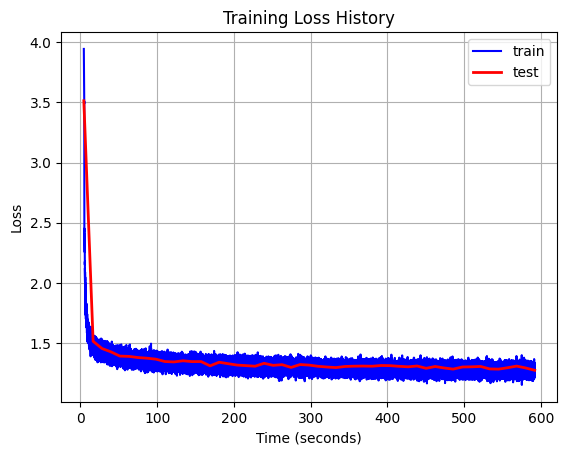

In [42]:
# plot the loss history
import matplotlib.pyplot as plt
import os

plt.plot(time_history, loss_history, '-', label='train', color="blue")
plt.plot(time_test_history, loss_test_history, '-', label='test', lw=2, color="red")
plt.xlabel("Time (seconds)")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.title("Training Loss History")
plt.grid()

folder = "plots"
os.makedirs(folder, exist_ok=True)
plt.savefig(os.path.join(folder, "loss_history1.png"))

In [ ]:
B = 1
seed = 42
rng = jax.random.PRNGKey(seed)
prompt = "hello my fri"
# prompt_int = encode(prompt.lower())
prompt_int = jnp.array([ [char_to_int.get(c, len(char_set)) for c in prompt.lower()[:64]] ], dtype=jnp.int32)

gen_len = 1000
out_ids = generation.generate_tokens(model, params, rng, prompt_int, gen_len, block_size=64, 
                          temperature=0.7, sample=True)
print('generated ids shape:', out_ids.shape)
print('generated text:')
generated_text = ''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0]))
# concatenate with prompt
print(prompt + generated_text)
#print(''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0])))

generated ids shape: (1, 1000)
generated text:
hello my fri i mah h wo as l h shos danona leninaphan bh feep es chonis ch s riza clid m bop uneveninho ierin ipa inoni wese iperatie ans an wanjan fide where athich fan t anatan olere ughorenonanonice t t trarelon atelefud t t r s ot ken m t pe itoses inelel wesconeton g of want s bima s t on min iles brg ma achin podinal seekamin tororor gin oga fles th cepeshere ispe xe r dr pelalinachenal arous meral in houroceter s an ted ainofheph manelin ilinanachy sy phin cime ofa inan s li menina onerabinis che s terinof anex benda idbleram s di c t s tata poraro onden b ceanam st s trin tet fun is flyc yapotharhalim rymis ros de coned phanoppon t alseanel ganis tornowl oleert s h bon s kaviginenonin s oneume chere faronilustais it thoner s t arlonspo a blas in ilche oumalimanan watorerd anenderonenanan c s acale ore walcheleru cr pis bureanostasthin s m thubrivan amistichinane ch hera la dhuks pon tr one nenexe miror s winiorertamafie nglema ft j

In [46]:
# define optax optimizer
learning_rate = 0.004
# Create Adam optimizer (Optax)
tx = optax.sgd(learning_rate=learning_rate, momentum=0.0)
# Initialize optimizer state for current params
opt_state = tx.init(params)
print(f"Initialized optimizer: Adam lr={learning_rate}")

Initialized optimizer: Adam lr=0.004


In [47]:
niter = 100_000
B, T = 1, 32
loss_history = []
time_history = []
time_test_history = []
loss_test_history = []
time_start = time.time()
for it in range(niter):
    batch = get_batch(train_text_int, B, T)
    input, target = batch[0], batch[1]
    params_new, opt_state_new, metrics = train_step(params, opt_state, input, target, tx)

    # update params and opt_state
    params = params_new
    opt_state = opt_state_new
    acc = metrics['acc']
    acc_last = metrics['acc_last']
    loss = metrics['loss']
    
    loss_history.append(loss)
    time_history.append(time.time() - time_start)
    
    if it % (niter // 50) == 0 or it == niter - 1:
        time_since_start = time.time() - time_start
        # compute loss on test set
        B_test, T_test = 1024, 32
        test_batch = get_batch(test_text_int, B_test, T_test)
        test_input, test_target = test_batch[0], test_batch[1]
        test_logits = model.apply({"params": params}, test_input)
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
        test_acc = test_metrics['acc']
        test_acc_last = test_metrics['acc_last']
        loss_test_history.append(test_loss)
        time_test_history.append(time_since_start)
        print(f"iteration {it:_}  time: {time_since_start:.1f} seconds")
        print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
        print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
        print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
        print()


iteration 0  time: 2.9 seconds
	 	 loss(train :: test): 1.3018 :: 1.2840
	 	 accuracy (train :: test): 56.2% :: 59.6%
	 	 accuracy (last character) (train :: test): 100.0% :: 62.7%

iteration 2_000  time: 6.0 seconds
	 	 loss(train :: test): 1.7553 :: 1.2941
	 	 accuracy (train :: test): 56.2% :: 59.5%
	 	 accuracy (last character) (train :: test): 0.0% :: 64.5%

iteration 4_000  time: 9.3 seconds
	 	 loss(train :: test): 1.0490 :: 1.2844
	 	 accuracy (train :: test): 68.8% :: 59.8%
	 	 accuracy (last character) (train :: test): 100.0% :: 63.7%

iteration 6_000  time: 12.6 seconds
	 	 loss(train :: test): 1.0773 :: 1.2722
	 	 accuracy (train :: test): 65.6% :: 59.9%
	 	 accuracy (last character) (train :: test): 100.0% :: 66.9%

iteration 8_000  time: 15.7 seconds
	 	 loss(train :: test): 1.5210 :: 1.2769
	 	 accuracy (train :: test): 46.9% :: 59.8%
	 	 accuracy (last character) (train :: test): 100.0% :: 62.4%

iteration 10_000  time: 18.8 seconds
	 	 loss(train :: test): 1.7234 :: 1.

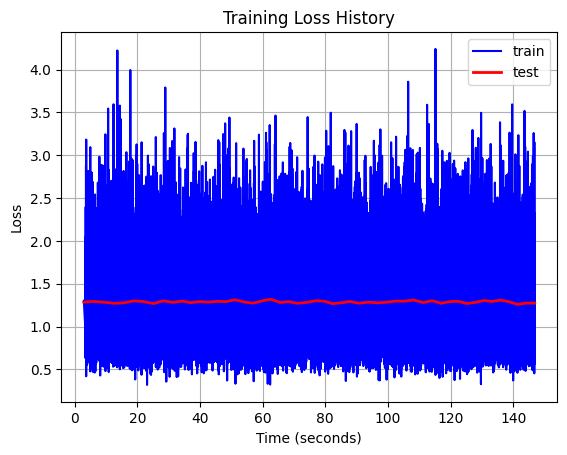

In [48]:
plt.plot(time_history, loss_history, '-', label='train', color="blue")
plt.plot(time_test_history, loss_test_history, '-', label='test', lw=2, color="red")
plt.xlabel("Time (seconds)")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.title("Training Loss History")
plt.grid()

folder = "plots"
os.makedirs(folder, exist_ok=True)
plt.savefig(os.path.join(folder, "loss_history2.png"))

In [50]:
B = 1
seed = 42
rng = jax.random.PRNGKey(seed)
prompt = "hello my fri"
# prompt_int = encode(prompt.lower())
prompt_int = jnp.array([ [char_to_int.get(c, len(char_set)) for c in prompt.lower()[:64]] ], dtype=jnp.int32)

gen_len = 1000
out_ids = generation.generate_tokens(model, params, rng, prompt_int, 3, block_size=64, 
                          temperature=0.7, sample=True)
print('generated ids shape:', out_ids.shape)
print('generated text:')
generated_text = ''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0]))
# concatenate with prompt
print(prompt + generated_text)
#print(''.join(int_to_char.get(int(x), '?') for x in list(out_ids[0])))

generated ids shape: (1, 3)
generated text:
hello my fri i 


In [12]:
# vocab size
vocab_size= len(char_set)

# internal model dimensions
d_model=512

# number of attention heads
n_heads=8

# number of Transformer layers
n_layers=4

# maximum sequence length
max_len=256

model, params = create_train_state(key, vocab_size, d_model, n_layers, n_heads, max_len)

In [19]:
niter = 100_000
B, T = 64, 32
loss_history = []
time_history = []
time_test_history = []
loss_test_history = []
time_start = time.time()
for it in range(niter):
    batch = get_batch(train_text_int, B, T)
    input, target = batch[0], batch[1]
    params_new, opt_state_new, metrics = train_step(params, opt_state, input, target, tx)

    # update params and opt_state
    params = params_new
    opt_state = opt_state_new
    acc = metrics['acc']
    acc_last = metrics['acc_last']
    loss = metrics['loss']
    
    loss_history.append(loss)
    time_history.append(time.time() - time_start)
    
    if it % (niter // 50) == 0 or it == niter - 1:
        time_since_start = time.time() - time_start
        # compute loss on test set
        B_test, T_test = 1024, 32
        test_batch = get_batch(test_text_int, B_test, T_test)
        test_input, test_target = test_batch[0], test_batch[1]
        test_logits = model.apply({"params": params}, test_input)
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
        test_acc = test_metrics['acc']
        test_acc_last = test_metrics['acc_last']
        loss_test_history.append(test_loss)
        time_test_history.append(time_since_start)
        print(f"iteration {it:_}  time: {time_since_start:.1f} seconds")
        print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
        print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
        print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
        print()


iteration 0  time: 11.1 seconds
	 	 loss(train :: test): 3.7004 :: 5.8848
	 	 accuracy (train :: test): 4.5% :: 17.2%
	 	 accuracy (last character) (train :: test): 4.7% :: 17.9%

iteration 2_000  time: 48.9 seconds
	 	 loss(train :: test): 1.8181 :: 1.7854
	 	 accuracy (train :: test): 44.0% :: 45.3%
	 	 accuracy (last character) (train :: test): 53.1% :: 47.7%

iteration 4_000  time: 81.3 seconds
	 	 loss(train :: test): 1.7750 :: 1.7616
	 	 accuracy (train :: test): 45.8% :: 45.8%
	 	 accuracy (last character) (train :: test): 37.5% :: 47.7%

iteration 6_000  time: 113.7 seconds
	 	 loss(train :: test): 2.0168 :: 2.0453
	 	 accuracy (train :: test): 39.2% :: 37.7%
	 	 accuracy (last character) (train :: test): 45.3% :: 38.8%

iteration 8_000  time: 146.0 seconds
	 	 loss(train :: test): 1.9584 :: 1.9731
	 	 accuracy (train :: test): 40.0% :: 39.4%
	 	 accuracy (last character) (train :: test): 48.4% :: 37.4%

iteration 10_000  time: 178.2 seconds
	 	 loss(train :: test): 1.9466 :: 1

In [15]:
# define optax optimizer
learning_rate = 0.01
# Create Adam optimizer (Optax)
tx = optax.adam(learning_rate=learning_rate)
# Initialize optimizer state for current params
opt_state = tx.init(params)
print(f"Initialized optimizer: Adam lr={learning_rate}")

Initialized optimizer: Adam lr=0.01


In [16]:
niter = 100_000
B, T = 128, 32
loss_history = []
time_history = []
time_test_history = []
loss_test_history = []
time_start = time.time()
for it in range(niter):
    batch = get_batch(train_text_int, B, T)
    input, target = batch[0], batch[1]
    params_new, opt_state_new, metrics = train_step(params, opt_state, input, target, tx)

    # update params and opt_state
    params = params_new
    opt_state = opt_state_new
    acc = metrics['acc']
    acc_last = metrics['acc_last']
    loss = metrics['loss']
    
    loss_history.append(loss)
    time_history.append(time.time() - time_start)
    
    if it % (niter // 50) == 0 or it == niter - 1:
        time_since_start = time.time() - time_start
        # compute loss on test set
        B_test, T_test = 1024, 32
        test_batch = get_batch(test_text_int, B_test, T_test)
        test_input, test_target = test_batch[0], test_batch[1]
        test_logits = model.apply({"params": params}, test_input)
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
        test_acc = test_metrics['acc']
        test_acc_last = test_metrics['acc_last']
        loss_test_history.append(test_loss)
        time_test_history.append(time_since_start)
        print(f"iteration {it:_}  time: {time_since_start:.1f} seconds")
        print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
        print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
        print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
        print()


iteration 0  time: 9.0 seconds
	 	 loss(train :: test): 3.9554 :: 4.0577
	 	 accuracy (train :: test): 2.2% :: 17.1%
	 	 accuracy (last character) (train :: test): 2.3% :: 16.0%

iteration 2_000  time: 24.7 seconds
	 	 loss(train :: test): 2.3319 :: 2.3509
	 	 accuracy (train :: test): 28.9% :: 29.2%
	 	 accuracy (last character) (train :: test): 23.4% :: 27.8%

iteration 4_000  time: 35.0 seconds
	 	 loss(train :: test): 2.3445 :: 2.3631
	 	 accuracy (train :: test): 29.0% :: 28.5%
	 	 accuracy (last character) (train :: test): 23.4% :: 26.7%

iteration 6_000  time: 45.2 seconds
	 	 loss(train :: test): 2.2490 :: 2.3087
	 	 accuracy (train :: test): 30.6% :: 30.1%
	 	 accuracy (last character) (train :: test): 32.8% :: 26.9%

iteration 8_000  time: 55.4 seconds
	 	 loss(train :: test): 2.2687 :: 2.2806
	 	 accuracy (train :: test): 30.2% :: 31.0%
	 	 accuracy (last character) (train :: test): 22.7% :: 28.2%

iteration 10_000  time: 65.7 seconds
	 	 loss(train :: test): 2.2519 :: 2.258

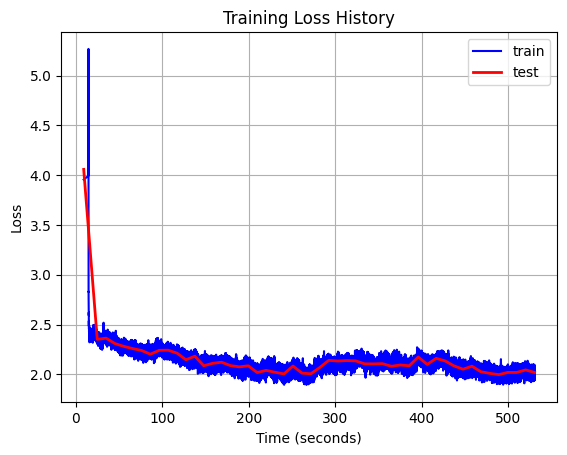

In [18]:
# plot the loss history
import matplotlib.pyplot as plt
import os

plt.plot(time_history, loss_history, '-', label='train', color="blue")
plt.plot(time_test_history, loss_test_history, '-', label='test', lw=2, color="red")
plt.xlabel("Time (seconds)")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.title("Training Loss History")
plt.grid()

folder = "plots"
os.makedirs(folder, exist_ok=True)
plt.savefig(os.path.join(folder, "loss_history3.png"))

In [15]:
# define optax optimizer
learning_rate = 0.0001
# Create Adam optimizer (Optax)
tx = optax.adam(learning_rate=learning_rate)
# Initialize optimizer state for current params
opt_state = tx.init(params)
print(f"Initialized optimizer: Adam lr={learning_rate}")



Initialized optimizer: Adam lr=0.0001


In [16]:
niter = 100_000
B, T = 128, 32
loss_history = []
time_history = []
time_test_history = []
loss_test_history = []
time_start = time.time()
for it in range(niter):
    batch = get_batch(train_text_int, B, T)
    input, target = batch[0], batch[1]
    params_new, opt_state_new, metrics = train_step(params, opt_state, input, target, tx)

    # update params and opt_state
    params = params_new
    opt_state = opt_state_new
    acc = metrics['acc']
    acc_last = metrics['acc_last']
    loss = metrics['loss']
    
    loss_history.append(loss)
    time_history.append(time.time() - time_start)
    
    if it % (niter // 50) == 0 or it == niter - 1:
        time_since_start = time.time() - time_start
        # compute loss on test set
        B_test, T_test = 1024, 32
        test_batch = get_batch(test_text_int, B_test, T_test)
        test_input, test_target = test_batch[0], test_batch[1]
        test_logits = model.apply({"params": params}, test_input)
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
        test_acc = test_metrics['acc']
        test_acc_last = test_metrics['acc_last']
        loss_test_history.append(test_loss)
        time_test_history.append(time_since_start)
        print(f"iteration {it:_}  time: {time_since_start:.1f} seconds")
        print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
        print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
        print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
        print()


iteration 0  time: 12.5 seconds
	 	 loss(train :: test): 3.9525 :: 3.4887
	 	 accuracy (train :: test): 2.1% :: 5.1%
	 	 accuracy (last character) (train :: test): 0.8% :: 4.8%

iteration 2_000  time: 34.3 seconds
	 	 loss(train :: test): 1.6144 :: 1.6355
	 	 accuracy (train :: test): 50.2% :: 50.2%
	 	 accuracy (last character) (train :: test): 49.2% :: 49.9%

iteration 4_000  time: 50.4 seconds
	 	 loss(train :: test): 1.5450 :: 1.5326
	 	 accuracy (train :: test): 53.4% :: 52.9%
	 	 accuracy (last character) (train :: test): 48.4% :: 56.4%

iteration 6_000  time: 66.8 seconds
	 	 loss(train :: test): 1.5106 :: 1.4881
	 	 accuracy (train :: test): 53.1% :: 54.2%
	 	 accuracy (last character) (train :: test): 45.3% :: 56.2%

iteration 8_000  time: 82.7 seconds
	 	 loss(train :: test): 1.4329 :: 1.4656
	 	 accuracy (train :: test): 56.3% :: 54.5%
	 	 accuracy (last character) (train :: test): 55.5% :: 59.8%

iteration 10_000  time: 98.9 seconds
	 	 loss(train :: test): 1.4454 :: 1.4499

In [22]:
niter = 100_000
B, T = 128, 32
loss_history = []
time_history = []
time_test_history = []
loss_test_history = []
time_start = time.time()
for it in range(niter):
    key, subkey = jax.random.split(key)
    batch = get_batch(train_text_int, B, T)
    input, target = batch[0], batch[1]
    params_new, opt_state_new, metrics = train_step(params, opt_state, input, target, tx, subkey)

    # update params and opt_state
    params = params_new
    opt_state = opt_state_new
    acc = metrics['acc']
    acc_last = metrics['acc_last']
    loss = metrics['loss']
    
    loss_history.append(loss)
    time_history.append(time.time() - time_start)
    
    if it % (niter // 50) == 0 or it == niter - 1:
        time_since_start = time.time() - time_start
        # compute loss on test set
        B_test, T_test = 1024, 32
        test_batch = get_batch(test_text_int, B_test, T_test)
        test_input, test_target = test_batch[0], test_batch[1]
        test_logits = model.apply({"params": params}, test_input, train = False)
        test_loss, test_metrics = loss_and_metrics(test_logits, test_target)
        test_acc = test_metrics['acc']
        test_acc_last = test_metrics['acc_last']
        loss_test_history.append(test_loss)
        time_test_history.append(time_since_start)
        print(f"iteration {it:_}  time: {time_since_start:.1f} seconds")
        print(f"\t \t loss(train :: test): {loss:.4f} :: {test_loss:.4f}")
        print(f"\t \t accuracy (train :: test): {100*acc:.1f}% :: {100*test_acc:.1f}%")
        print(f"\t \t accuracy (last character) (train :: test): {100*acc_last:.1f}% :: {100*test_acc_last:.1f}%")
        print()


iteration 0  time: 0.0 seconds
	 	 loss(train :: test): 4.7076 :: 4.1537
	 	 accuracy (train :: test): 17.2% :: 7.4%
	 	 accuracy (last character) (train :: test): 13.3% :: 7.1%

iteration 2_000  time: 58.2 seconds
	 	 loss(train :: test): 1.7167 :: 1.5842
	 	 accuracy (train :: test): 47.9% :: 51.4%
	 	 accuracy (last character) (train :: test): 51.6% :: 51.4%

iteration 4_000  time: 110.4 seconds
	 	 loss(train :: test): 1.6179 :: 1.5073
	 	 accuracy (train :: test): 49.5% :: 53.7%
	 	 accuracy (last character) (train :: test): 50.8% :: 55.0%

iteration 6_000  time: 162.9 seconds
	 	 loss(train :: test): 1.4746 :: 1.4709
	 	 accuracy (train :: test): 54.2% :: 54.5%
	 	 accuracy (last character) (train :: test): 56.2% :: 58.8%

iteration 8_000  time: 217.6 seconds
	 	 loss(train :: test): 1.4543 :: 1.4603
	 	 accuracy (train :: test): 54.3% :: 54.9%
	 	 accuracy (last character) (train :: test): 60.9% :: 55.6%

iteration 10_000  time: 270.6 seconds
	 	 loss(train :: test): 1.4825 :: 1